**STEP 01 IMPORT LIBRARIES**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder

**STEP 02 LOAD DATASET**

In [2]:
df = pd.read_csv("engineered_accessibility_dataset.csv")

**STEP 3 ENCODE TARGET**

In [3]:
encoder = LabelEncoder()

df["Accessibility_Category"] = encoder.fit_transform(
    df["Accessibility_Category"]
)

**STEP 4 FEATURES & TARGET**

In [4]:
X = df.drop(columns=[
    "Accessibility_Score",
    "Accessibility_Category",
    "Improvement_Priority",
    "Location_ID",
    "Location_Name"
], errors="ignore")

y = df["Accessibility_Category"]

**STEP 5 TRAIN THE SPLIT**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**STEP 6 UNIVERSAL EVALUATION FUNCTION**

In [6]:
def evaluate_classifier(model, name):

  model.fit(X_train, y_train)

  prediction = model.predict(X_test)

  accuracy = accuracy_score(y_test, prediction)

  precision = precision_score(
      y_test,
      prediction,
      average="weighted"
  )

  recall = recall_score(
      y_test,
      prediction,
      average="weighted"
  )

  f1 = f1_score(
      y_test,
      prediction,
      average="weighted"
  )

  kappa = cohen_kappa_score(
      y_test,
      prediction
  )

  print("="*60)
  print(name)
  print("="*60)

  print("Accuracy :", round(accuracy,3))
  print("Precision :", round(precision,3))
  print("Recall :", round(recall,3))
  print("F1 Score :", round(f1,3))
  print("Kappa :", round(kappa,3))

  print("\nClassification Report\n")

  print(classification_report(y_test,prediction))

  cm = confusion_matrix(y_test,prediction)

  plt.figure(figsize=(6,5))

  sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="Blues"
  )

  plt.title(name)

  plt.xlabel("Predicted")

  plt.ylabel("Actual")

  plt.show()

  return accuracy, precision, recall, f1, kappa

**STEP 7 LOGISTIC REGRESSION**

Logistic Regression
Accuracy : 0.62
Precision : 0.596
Recall : 0.62
F1 Score : 0.6
Kappa : 0.442

Classification Report

              precision    recall  f1-score   support

           0       0.44      0.44      0.44        50
           1       0.61      0.62      0.62        32
           2       0.44      0.22      0.29        32
           3       0.74      0.87      0.80        86

    accuracy                           0.62       200
   macro avg       0.56      0.54      0.54       200
weighted avg       0.60      0.62      0.60       200



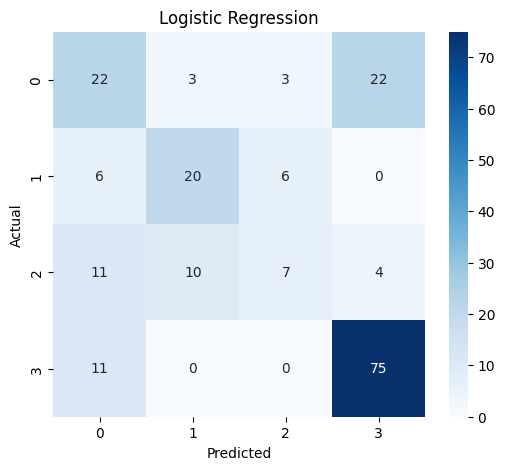

(0.62,
 0.5962766276627662,
 0.62,
 0.6000479912244618,
 np.float64(0.4421199442119944))

In [7]:
logistic = LogisticRegression(max_iter=1000)

evaluate_classifier(
    logistic,
    "Logistic Regression"
)

**STEP 8 DECISION TREE**

Decision Tree
Accuracy : 0.56
Precision : 0.562
Recall : 0.56
F1 Score : 0.56
Kappa : 0.371

Classification Report

              precision    recall  f1-score   support

           0       0.33      0.38      0.36        50
           1       0.66      0.66      0.66        32
           2       0.35      0.28      0.31        32
           3       0.74      0.73      0.74        86

    accuracy                           0.56       200
   macro avg       0.52      0.51      0.51       200
weighted avg       0.56      0.56      0.56       200



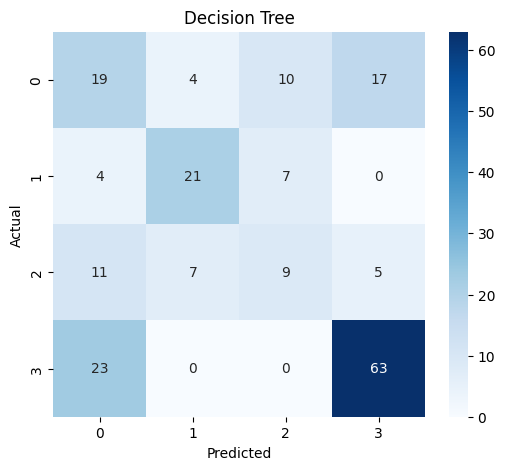

(0.56,
 0.5624238310708898,
 0.56,
 0.560282324405923,
 np.float64(0.37106918238993714))

In [8]:
tree = DecisionTreeClassifier(
    random_state=42
)

evaluate_classifier(
    tree,
    "Decision Tree"
)

**STEP 9 RANDOM FOREST**

Random Forest
Accuracy : 0.68
Precision : 0.653
Recall : 0.68
F1 Score : 0.659
Kappa : 0.53

Classification Report

              precision    recall  f1-score   support

           0       0.51      0.40      0.45        50
           1       0.74      0.78      0.76        32
           2       0.50      0.34      0.41        32
           3       0.76      0.93      0.84        86

    accuracy                           0.68       200
   macro avg       0.63      0.61      0.61       200
weighted avg       0.65      0.68      0.66       200



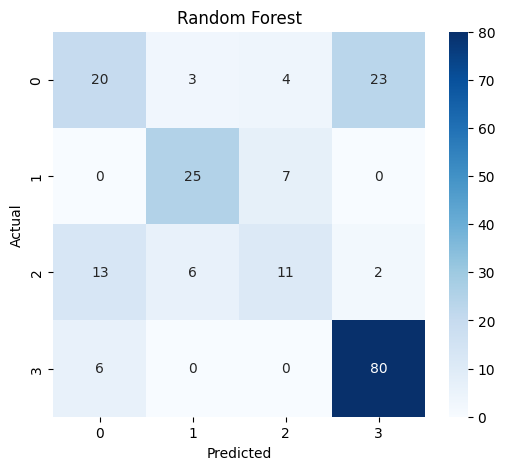

(0.68,
 0.6534712346477052,
 0.68,
 0.6589662810428737,
 np.float64(0.5298956956074629))

In [9]:
forest = RandomForestClassifier(
    random_state=42
)

evaluate_classifier(
    forest,
    "Random Forest"
)

**STEP 10 BAGGING**

Bagging
Accuracy : 0.665
Precision : 0.626
Recall : 0.665
F1 Score : 0.637
Kappa : 0.509

Classification Report

              precision    recall  f1-score   support

           0       0.51      0.44      0.47        50
           1       0.68      0.78      0.72        32
           2       0.35      0.19      0.24        32
           3       0.78      0.93      0.85        86

    accuracy                           0.67       200
   macro avg       0.58      0.58      0.57       200
weighted avg       0.63      0.67      0.64       200



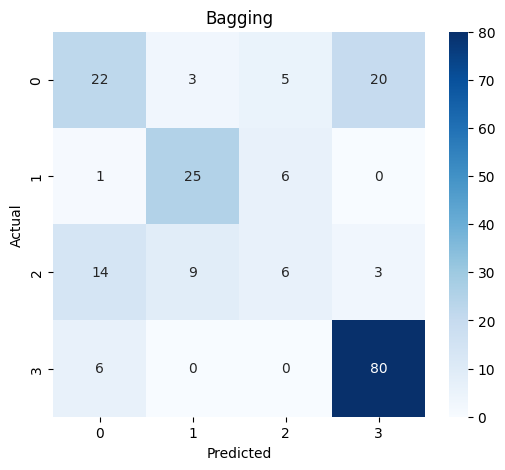

(0.665,
 0.6264662556118601,
 0.665,
 0.6374264363685321,
 np.float64(0.5085093896713615))

In [10]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

evaluate_classifier(
    bagging,
    "Bagging"
)

**STEP 11 SVM**

Support Vector Machine
Accuracy : 0.445
Precision : 0.268
Recall : 0.445
F1 Score : 0.334
Kappa : 0.144

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.32      0.56      0.41        32
           2       0.00      0.00      0.00        32
           3       0.50      0.83      0.63        86

    accuracy                           0.45       200
   macro avg       0.21      0.35      0.26       200
weighted avg       0.27      0.45      0.33       200



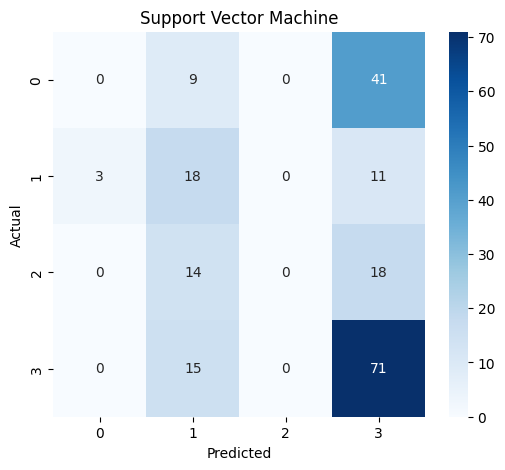

(0.445,
 0.26795339412360686,
 0.445,
 0.3344413295955146,
 np.float64(0.14391485423415085))

In [11]:
svm = SVC(
    probability=True,
    random_state=42
)

evaluate_classifier(
    svm,
    "Support Vector Machine"
)

**STEP 12 XGBOOST**

XGBoost
Accuracy : 0.705
Precision : 0.687
Recall : 0.705
F1 Score : 0.693
Kappa : 0.57

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.54      0.56        50
           1       0.72      0.66      0.69        32
           2       0.42      0.34      0.38        32
           3       0.84      0.95      0.89        86

    accuracy                           0.70       200
   macro avg       0.64      0.62      0.63       200
weighted avg       0.69      0.70      0.69       200



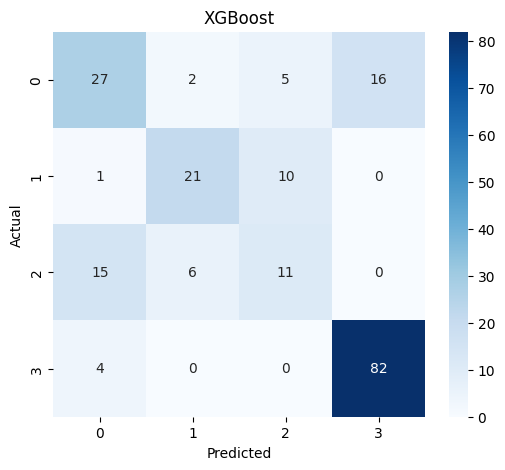

(0.705,
 0.6869673163017677,
 0.705,
 0.6932897168958195,
 np.float64(0.5703153448401428))

In [12]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

evaluate_classifier(
    xgb,
    "XGBoost"
)

**STEP 13 K-FOLD VALIDATION**

In [13]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        random_state=42
    ),

    "SVM": SVC(),

    "XGBoost": XGBClassifier(
        eval_metric="mlogloss"
    )

}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(name)

    print("Average Accuracy:",round(scores.mean(),3))

    print("-----------------------------")

Logistic Regression
Average Accuracy: 0.626
-----------------------------
Decision Tree
Average Accuracy: 0.575
-----------------------------
Random Forest
Average Accuracy: 0.705
-----------------------------
Bagging
Average Accuracy: 0.688
-----------------------------
SVM
Average Accuracy: 0.466
-----------------------------
XGBoost
Average Accuracy: 0.732
-----------------------------


**STEP 14 MODEL COMPARISION**

In [14]:
results = []

for name, model in models.items():

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(y_test,prediction),

        "Precision":precision_score(
            y_test,
            prediction,
            average="weighted"
        ),

        "Recall":recall_score(
            y_test,
            prediction,
            average="weighted"
        ),

        "F1":f1_score(
            y_test,
            prediction,
            average="weighted"
        ),

        "Kappa":cohen_kappa_score(
            y_test,
            prediction
        )

    })

comparison = pd.DataFrame(results)

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,Kappa
5,XGBoost,0.705,0.686967,0.705,0.693290,0.570315
2,Random Forest,0.680,0.653471,0.680,0.658966,0.529896
0,Logistic Regression,0.620,0.596277,0.620,0.600048,0.442120
3,Bagging,0.610,0.601816,0.610,0.603643,0.438202
1,Decision Tree,0.560,0.562424,0.560,0.560282,0.371069
4,SVM,0.445,0.267953,0.445,0.334441,0.143915


**STEP 15 ACCURACY CHART**

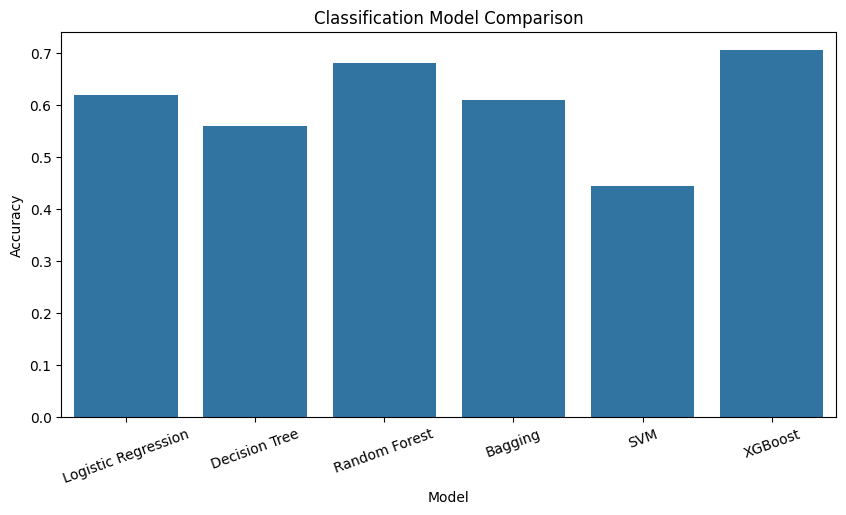

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.xticks(rotation=20)

plt.title("Classification Model Comparison")

plt.show()

**STEP 16 SAVE BEST MODEL**

In [16]:
import joblib
joblib.dump(
    forest,
    "best_classification_model.pkl"
)

['best_classification_model.pkl']